# MVP — Diagnóstico de calidad de red y soporte a decisión de inversión/mantenimiento (grano mensual)

**TFM Grupo 1 — OBS Business School**
**Ejecutar:** Kernel → Restart → Run All (debe completar sin error)

> Variante a grano **site×mes** del notebook principal (`mvp_diagnostico_red-final.ipynb`, grano semanal) — ver `entregables/tasks-entrega3.md` para contexto de por qué se corrió este experimento (el cliente reportó ver relación KPI↔queja al unificar datos a nivel más agregado).

---

| Sección | Owner | Input | Output |
|---------|-------|-------|--------|
| §0 Setup | Dev-1 | — | Constantes, paths |
| §1 Carga | Dev-1 | `db_files/` | `df_claims`, `df_location`, `df_kpis` |
| §2 Dataset mensual | Dev-1 | DataFrames crudos | `df_monthly` + Parquet |
| §3 EDA | Dev-2 | `df_monthly` | Figuras, hallazgos |
| §4 Features + split | Dev-1 | `df_monthly` | `X_train/test`, `y_train/test` |
| §5 Modelos | Dev-2 | X/y splits | `model_rules/lr/xgb` |
| §6 Evaluación | Dev-2 | predicciones | `df_metrics`, figura AUC-PR |
| §7 SHAP | Dev-3 | `model_xgb`, `X_test` | `shap_values`, figuras |
| §8 Clustering | Dev-3 | `df_monthly` | `df_sites_clustered` |
| §9 Ranking | Dev-3 | score + SHAP + clusters | `df_ranking` + Parquet |

In [1]:
# Colab no trae optuna/shap/xgboost preinstalados -- instalar solo si hace falta.
try:
    import google.colab  # noqa: F401
    %pip install -q optuna shap xgboost
except ImportError:
    pass

## §0 — Setup & configuración global

**Owner:** Dev-1  
**Input:** —  
**Output:** constantes globales, paths  
**Dependencias:** ninguna

In [2]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Detecta Colab vs. entorno local — permite un solo notebook para ambos casos
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Carpeta dedicada del notebook en Drive (separada del remote DVC)
    drive.mount('/content/drive')
    ROOT_DIR = Path('/content/drive/MyDrive/TFM-local')
else:
    # Permite importar desde src/ independientemente del CWD
    ROOT_DIR = Path().resolve().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

# — Reproducibilidad —
RANDOM_STATE      = 42

# — Parámetros de modelado —
ROLLING_WINDOW    = 30           # días (ventana ampliada — ver build_monthly_kpis)
MONTH_ANCHOR      = "M"          # mes calendario
TEST_CUTOFF_DATE  = "2026-02-01" # split temporal train/test

# — Umbrales de negocio (derivados del EDA: entregables/eda-hallazgos.md) —
AVA_THRESHOLD     = 0.98         # tasa queja 3-4x por debajo
DC_THRESHOLD      = 0.02         # tasa queja 2x por encima
THP_THRESHOLD_MBP = 15.0         # Mbps, tasa queja 2-3x por debajo

# — Columnas clave —
SITE_ID_COL  = "site_id"
MONTH_COL    = "mes"
TARGET_COL   = "es_reclamo_mensual"

# — Paths —
OUTPUT_DIR  = ROOT_DIR / "output"
FIGURES_DIR = OUTPUT_DIR / "mensual" / "figures"
DATA_MONTHLY = OUTPUT_DIR / "modeling_dataset_monthly.parquet"
RANKING_PATH = OUTPUT_DIR / "mensual" / "ranking_sitios.parquet"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT_DIR   : {ROOT_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")
print(f"DATA_MONTHLY: {DATA_MONTHLY}")
print(f"RANDOM_STATE = {RANDOM_STATE} | TEST_CUTOFF = {TEST_CUTOFF_DATE}")

ROOT_DIR   : /Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1
OUTPUT_DIR : /Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output
DATA_MONTHLY: /Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output/modeling_dataset_monthly.parquet
RANDOM_STATE = 42 | TEST_CUTOFF = 2026-02-01


## §1 — Carga y validación de datos

**Owner:** Dev-1  
**Input:** archivos en `db_files/`  
**Output:** `df_claims`, `df_location`, `df_kpis`  
**Dependencias:** §0

In [3]:
# Si el Parquet mensual ya existe (workflow Colab compartido), no hace falta
# el repo completo ni db_files/ crudo — Dev-2/Dev-3 solo consumen df_monthly (§2).
if DATA_MONTHLY.exists():
    df_claims = df_location = df_kpis = None
    print("Parquet mensual ya disponible — se omite carga de datos crudos (§1).")
else:
    from src.build_modeling_dataset import load_from_files, normalize, validate_integrity

    df_claims, df_location, df_kpis = load_from_files(ROOT_DIR / "db_files")
    df_claims, df_location, df_kpis = normalize(df_claims, df_location, df_kpis)
    validate_integrity(df_claims, df_location, df_kpis)

    print(f"claims   : {df_claims.shape}")
    print(f"location : {df_location.shape}")
    print(f"kpis     : {df_kpis.shape}")

Parquet mensual ya disponible — se omite carga de datos crudos (§1).


In [4]:
# Verificando que los datos se carguen correctamente desde Google Drive
print(f"Expected DATA_MONTHLY path: {DATA_MONTHLY}")
print(f"Does DATA_MONTHLY exist? {DATA_MONTHLY.exists()}")

if not DATA_MONTHLY.exists():
    print(f"Contents of OUTPUT_DIR ({OUTPUT_DIR}):")
    for item in OUTPUT_DIR.iterdir():
        print(f"- {item.name}")
    print("Please ensure 'modeling_dataset_monthly.parquet' is directly within the 'output' folder in your TFM Drive directory, and that the filename is exactly correct.")


Expected DATA_MONTHLY path: /Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output/modeling_dataset_monthly.parquet
Does DATA_MONTHLY exist? True


## §2 — Dataset sitio × mes

**Owner:** Dev-1  
**Input:** `df_claims`, `df_location`, `df_kpis`  
**Output:** `df_monthly` → `output/modeling_dataset_monthly.parquet`  
**Dependencias:** §1

Punto de handoff crítico (H1): Dev-2 y Dev-3 leen desde el Parquet.

In [5]:
# df_monthly se construye con build_weekly() en src/build_modeling_dataset.py
# (agrega claims a sitio×mes, KPIs rolling leakage-safe, normaliza por USERS_4G).
# El notebook no reimplementa esa lógica — solo carga el Parquet ya generado.
if DATA_MONTHLY.exists():
    df_monthly = pd.read_parquet(DATA_MONTHLY)
    print(f"df_monthly cargado desde Parquet: {df_monthly.shape}")
    print(f"Positivos: {df_monthly[TARGET_COL].sum()} / {len(df_monthly)} = {df_monthly[TARGET_COL].mean():.2%}")
else:
    raise FileNotFoundError(
        f"Parquet no encontrado: {DATA_MONTHLY}. "
        "Ejecutar `python src/build_modeling_dataset.py --grain monthly --source files` primero."
    )

df_monthly cargado desde Parquet: (15382, 14)
Positivos: 1576 / 15382 = 10.25%


## §3 — EDA diagnóstico

**Owner:** Dev-2  
**Input:** `df_monthly` (vía Parquet si §2 no está corrido)  
**Output:** figuras en `output/figures/`, hallazgos documentados  
**Dependencias:** §2 (Parquet H1)

Distribución del target:
es_reclamo_mensual
0    0.897543
1    0.102457
Name: proporción, dtype: float64


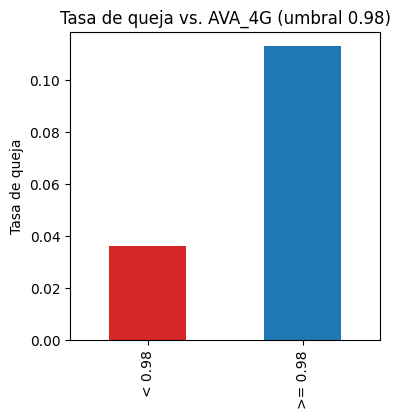

< 0.98     0.036232
>= 0.98    0.112733
Name: es_reclamo_mensual, dtype: float64


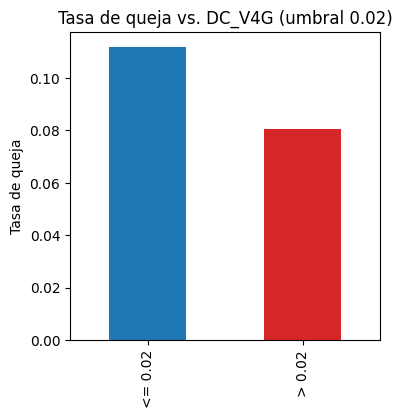

<= 0.02    0.111888
> 0.02     0.080569
Name: es_reclamo_mensual, dtype: float64


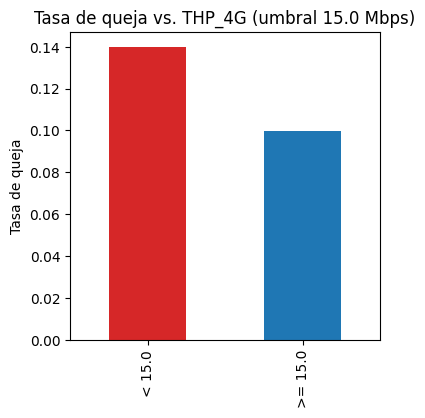

< 15.0     0.140032
>= 15.0    0.099601
Name: es_reclamo_mensual, dtype: float64


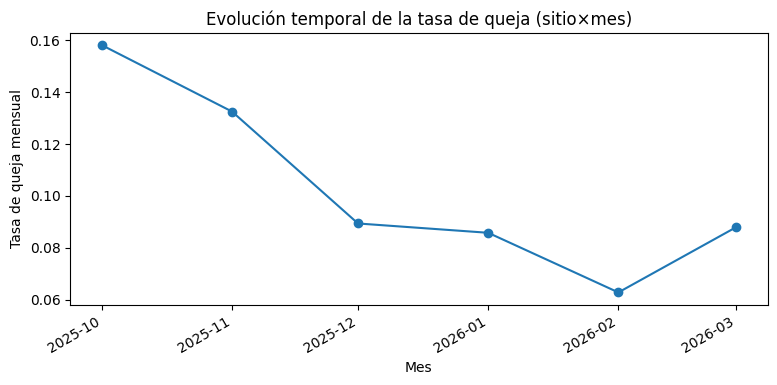

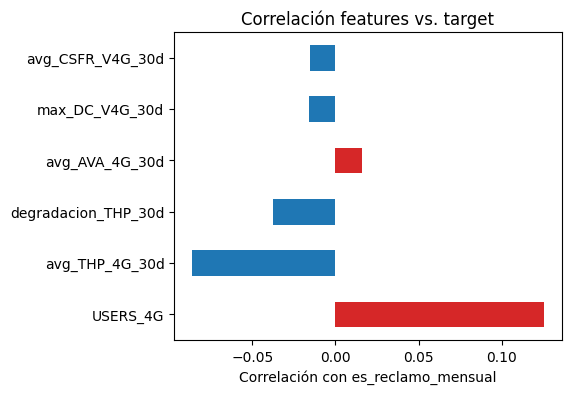

USERS_4G               0.125474
avg_THP_4G_30d        -0.086306
degradacion_THP_30d   -0.037473
avg_AVA_4G_30d         0.015933
max_DC_V4G_30d        -0.015646
avg_CSFR_V4G_30d      -0.015343
Name: es_reclamo_mensual, dtype: float64


In [6]:
# Asegurar que df_monthly está disponible (puede cargar sin correr §2)
if "df_monthly" not in dir():
    df_monthly = pd.read_parquet(DATA_MONTHLY)

# 1. Distribución del target
print("Distribución del target:")
print(df_monthly[TARGET_COL].value_counts(normalize=True).rename("proporción"))


def _tasa_por_bucket(df: pd.DataFrame, col: str, umbral: float, mayor_es_malo: bool) -> pd.Series:
    """Tasa de queja por encima/debajo del umbral de negocio de la columna."""
    d = df.dropna(subset=[col])
    if mayor_es_malo:
        bucket = np.where(d[col] > umbral, f"> {umbral}", f"<= {umbral}")
    else:
        bucket = np.where(d[col] < umbral, f"< {umbral}", f">= {umbral}")
    return d.groupby(bucket)[TARGET_COL].mean()


# 2. Tasa queja vs. bucket AVA
tasa_ava = _tasa_por_bucket(df_monthly, "avg_AVA_4G_30d", AVA_THRESHOLD, mayor_es_malo=False)
fig_ava_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_ava.plot(kind="bar", ax=ax, color=["#d62728", "#1f77b4"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. AVA_4G (umbral {AVA_THRESHOLD})")
fig_ava_bucket.savefig(FIGURES_DIR / "eda_ava_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_ava)

# 3. Tasa queja vs. bucket DC
tasa_dc = _tasa_por_bucket(df_monthly, "max_DC_V4G_30d", DC_THRESHOLD, mayor_es_malo=True)
fig_dc_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_dc.plot(kind="bar", ax=ax, color=["#1f77b4", "#d62728"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. DC_V4G (umbral {DC_THRESHOLD})")
fig_dc_bucket.savefig(FIGURES_DIR / "eda_dc_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_dc)

# 4. Tasa queja vs. bucket THP
tasa_thp = _tasa_por_bucket(df_monthly, "avg_THP_4G_30d", THP_THRESHOLD_MBP, mayor_es_malo=False)
fig_thp_bucket, ax = plt.subplots(figsize=(4, 4))
tasa_thp.plot(kind="bar", ax=ax, color=["#d62728", "#1f77b4"])
ax.set_ylabel("Tasa de queja")
ax.set_title(f"Tasa de queja vs. THP_4G (umbral {THP_THRESHOLD_MBP} Mbps)")
fig_thp_bucket.savefig(FIGURES_DIR / "eda_thp_bucket.png", dpi=150, bbox_inches="tight")
plt.show()
print(tasa_thp)

# 5. Evolución temporal de quejas
temporal = df_monthly.groupby(MONTH_COL)[TARGET_COL].agg(n_reclamos="sum", tasa="mean").reset_index()
temporal[MONTH_COL] = temporal[MONTH_COL].dt.start_time
fig_temporal, ax = plt.subplots(figsize=(9, 4))
ax.plot(temporal[MONTH_COL], temporal["tasa"], marker="o")
ax.set_ylabel("Tasa de queja mensual")
ax.set_xlabel("Mes")
ax.set_title("Evolución temporal de la tasa de queja (sitio×mes)")
fig_temporal.autofmt_xdate()
fig_temporal.savefig(FIGURES_DIR / "eda_temporal.png", dpi=150, bbox_inches="tight")
plt.show()

# 6. Correlación features vs. TARGET_COL
# Columnas de KPI disponibles en df_monthly ya en §3 (FEATURE_COLS se define recién en §4)
_KPI_COLS = ["avg_AVA_4G_30d", "max_DC_V4G_30d", "avg_THP_4G_30d", "degradacion_THP_30d", "avg_CSFR_V4G_30d", "USERS_4G"]
corr = df_monthly[_KPI_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
fig_correlation, ax = plt.subplots(figsize=(5, 4))
corr.plot(kind="barh", ax=ax, color=np.where(corr > 0, "#d62728", "#1f77b4"))
ax.set_xlabel(f"Correlación con {TARGET_COL}")
ax.set_title("Correlación features vs. target")
fig_correlation.savefig(FIGURES_DIR / "eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(corr)

> **Hallazgo:** A grano mensual (site×mes), la señal de los umbrales de negocio cambia respecto al semanal: `avg_THP_4G_30d < 15 Mbps` mantiene la dirección esperada (tasa de queja 0.140 vs 0.100, ~1.4x — similar al semanal), pero `avg_AVA_4G_30d < 0.98` y `max_DC_V4G_30d > 0.02` salen **invertidos**: AVA da 0.036 (sitios "malos") vs 0.113 (sitios "buenos") — justo al revés de lo esperado; DC da 0.081 (sitios con más caídas) vs 0.112 (sitios sin caídas) — también invertido. La correlación lineal más fuerte sigue siendo `USERS_4G` (r=0.125), no ningún KPI de calidad — igual que a grano semanal (todas las demás |r| < 0.09).
> **Implicación:** agregar a mes no revierte el patrón ya visto a grano semanal (señal débil, dominada por tráfico) — de hecho dos de los tres umbrales de negocio pierden sentido direccional al promediar/maximizar sobre ventanas más anchas (30d vs 7d). Es evidencia adicional de que la limitación está en qué mide `kpis_diario`, no en la resolución temporal elegida para agregarlo.

## §4 — Feature engineering y split temporal

**Owner:** Dev-1  
**Input:** `df_monthly`  
**Output:** `X_train`, `X_test`, `y_train`, `y_test`, `FEATURE_COLS`  
**Dependencias:** §2

Punto de handoff H2: Dev-2 y Dev-3 consumen estas variables directamente.

In [7]:
FEATURE_COLS = [
    "avg_AVA_4G_30d",
    "max_DC_V4G_30d",
    "avg_THP_4G_30d",
    "degradacion_THP_30d",
    "avg_CSFR_V4G_30d",
    "USERS_4G",
    # "reclamos_por_usuario" -- NO USAR: es n_reclamos_mes / USERS_4G, calculado con
    # el conteo de reclamos de la MISMO mes que define TARGET_COL -> data leakage directo.
    # Categoricals one-hot-encoded
    # "tipo_negocio_B2C", "tipo_negocio_B2B", "tipo_negocio_PREPAGO",
]

# Filas sin ventana rolling previa (primer mes con datos por sitio) quedan con nulos
# en FEATURE_COLS -- no es missing real, es artefacto de .shift(1).rolling(). Se descartan.
# degradacion_THP_30d puede dar inf si avg_THP_4G_30d es 0 (denominador) -- dropna() no
# atrapa inf, hay que convertirlo a NaN primero para que se descarte igual que los demás.
df_model = df_monthly.replace([np.inf, -np.inf], np.nan).dropna(subset=FEATURE_COLS).copy()
print(f"Filas descartadas (sin ventana rolling): {len(df_monthly) - len(df_model)} "
      f"({1 - len(df_model) / len(df_monthly):.1%})")

# Split temporal -- nunca aleatorio en series de tiempo
mask_train = df_model[MONTH_COL] < TEST_CUTOFF_DATE
df_train   = df_model[mask_train].copy()
df_test    = df_model[~mask_train].copy()

X_train = df_train[FEATURE_COLS]
y_train = df_train[TARGET_COL]
X_test  = df_test[FEATURE_COLS]
y_test  = df_test[TARGET_COL]

print(f"Train: {X_train.shape} | positivos={y_train.sum()} ({y_train.mean():.2%})")
print(f"Test : {X_test.shape}  | positivos={y_test.sum()} ({y_test.mean():.2%})")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Filas descartadas (sin ventana rolling): 1790 (11.6%)
Train: (8931, 6) | positivos=1157 (12.95%)
Test : (4661, 6)  | positivos=382 (8.20%)
Features (6): ['avg_AVA_4G_30d', 'max_DC_V4G_30d', 'avg_THP_4G_30d', 'degradacion_THP_30d', 'avg_CSFR_V4G_30d', 'USERS_4G']


## §5 — Modelos (baseline / LR / XGBoost)

**Owner:** Dev-2  
**Input:** `X_train`, `X_test`, `y_train`, `y_test`, `FEATURE_COLS`, `RANDOM_STATE`  
**Output:** `model_rules`, `model_lr`, `model_xgb`, `y_pred_*`, `y_prob_*`  
**Dependencias:** §4 (handoff H2)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
import optuna
from sklearn.impute import SimpleImputer # Import SimpleImputer

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Baseline de reglas ---
class RulesBaseline:
    """Flag si AVA < umbral OR DC > umbral OR THP < umbral (umbrales de negocio, EDA)."""

    def _rule_count(self, X: pd.DataFrame) -> pd.Series:
        return (
            (X["avg_AVA_4G_30d"] < AVA_THRESHOLD).astype(int)
            + (X["max_DC_V4G_30d"] > DC_THRESHOLD).astype(int)
            + (X["avg_THP_4G_30d"] < THP_THRESHOLD_MBP).astype(int)
        )

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self._rule_count(X) > 0).astype(int).to_numpy()

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        # Score continuo: fracción de las 3 reglas de negocio que dispara.
        prob_pos = (self._rule_count(X) / 3).to_numpy()
        return np.column_stack([1 - prob_pos, prob_pos])


model_rules = RulesBaseline()
y_pred_rules = model_rules.predict(X_test)
y_prob_rules = model_rules.predict_proba(X_test)[:, 1]

# --- Logistic Regression ---
# StandardScaler necesario: features en escalas muy distintas (AVA 0-1, USERS_4G hasta ~500+).
# Se agrega SimpleImputer para manejar NaNs antes del StandardScaler.
model_lr = make_pipeline(
    SimpleImputer(strategy='mean'), # Handle missing values
    StandardScaler(),
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE, solver="lbfgs"),
)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

# --- XGBoost + Optuna ---
# scale_pos_weight = n_neg/n_pos: equivalente a class_weight='balanced' en sklearn
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# CV interno para tuning: StratifiedKFold, no TimeSeriesSplit. Con ~0.7% de positivos
# concentrados en pocas semanas del train, TimeSeriesSplit produce folds sin ningún
# positivo (average_precision indefinido). El split train/test SÍ es estrictamente
# temporal (TEST_CUTOFF_DATE) -- ahí es donde importa evitar leakage hacia el futuro;
# el CV interno solo reordena semanas ya vistas en train para elegir hiperparámetros.
def objective(trial: optuna.Trial) -> float:
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 10),
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        eval_metric="aucpr",
    )
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        model = XGBClassifier(**params)
        # XGBoost can handle NaNs directly, so no imputer is strictly needed here,
        # but for consistency or if other models were added, an imputer could be included.
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_val)[:, 1]
        scores.append(average_precision_score(y_val, prob))
    return float(np.mean(scores))


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=50, show_progress_bar=False)

best_params = dict(study.best_params)
best_params.update(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric="aucpr")
model_xgb = XGBClassifier(**best_params)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

print(f"scale_pos_weight = {scale_pos_weight:.1f}")
print(f"Optuna best AUC-PR (CV interno): {study.best_value:.4f}")
print(f"Best params XGBoost: {best_params}")

/Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scale_pos_weight = 6.7
Optuna best AUC-PR (CV interno): 0.1949
Best params XGBoost: {'n_estimators': 288, 'max_depth': 2, 'learning_rate': 0.01275737651037814, 'subsample': 0.6610487241216071, 'colsample_bytree': 0.6370638662934981, 'min_child_weight': 2, 'scale_pos_weight': np.float64(6.719101123595506), 'random_state': 42, 'eval_metric': 'aucpr'}


## §6 — Evaluación comparativa

**Owner:** Dev-2  
**Input:** `y_test`, `y_pred_*`, `y_prob_*`  
**Output:** `df_metrics`, `fig_aucpr`  
**Dependencias:** §5

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    recall_score,
    precision_score,
    f1_score
)

In [10]:
# 1. Definición de las fuentes de datos para la evaluación
modelos_config = {
    "Reglas": {
        "preds": y_pred_rules,
        "probs": y_prob_rules,  # score continuo real (fracción de reglas disparadas), no binario
    },
    "LR": {
        "preds": y_pred_lr,
        "probs": y_prob_lr
    },
    "XGBoost": {
        "preds": y_pred_xgb,
        "probs": y_prob_xgb
    }
}

In [11]:
# 2. Cálculo de métricas e inicialización de la tabla
metricas_list = []

for nombre, data in modelos_config.items():
    auc_pr = average_precision_score(y_test, data["probs"])
    precision = precision_score(y_test, data["preds"], zero_division=0)
    recall = recall_score(y_test, data["preds"], zero_division=0)
    f1 = f1_score(y_test, data["preds"], zero_division=0)
    n_alertas = int(data["preds"].sum()) # Suma de predicciones positivas (clase 1)

    metricas_list.append({
        "modelo": nombre,
        "AUC-PR": round(auc_pr, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "n_alertas": n_alertas
    })

# Crear y mostrar el DataFrame final
df_metrics = pd.DataFrame(metricas_list)
print("=== Cuadro Comparativo de Modelos ===")
print(df_metrics.to_string(index=False))
print("-" * 50)


=== Cuadro Comparativo de Modelos ===
 modelo  AUC-PR  Precision  Recall  F1-Score  n_alertas
 Reglas  0.0850     0.0932  0.2932    0.1414       1202
     LR  0.1049     0.1019  0.3979    0.1623       1491
XGBoost  0.1082     0.1011  0.5576    0.1712       2107
--------------------------------------------------


Éxito: Gráfico guardado en '/Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output/mensual/figures/aucpr_models.png'


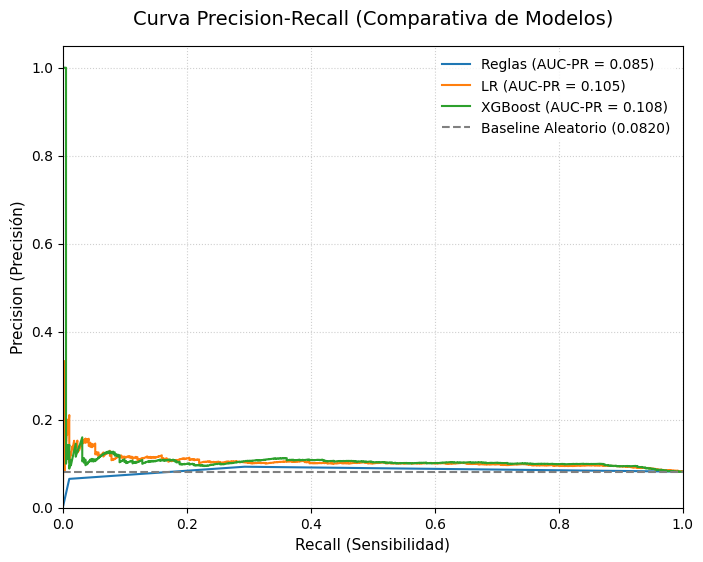

In [12]:
# 3. Generación y guardado del gráfico de Curvas Precision-Recall (PR)
fig_aucpr, ax = plt.subplots(figsize=(8, 6))

for nombre, data in modelos_config.items():
    precision, recall, _ = precision_recall_curve(y_test, data["probs"])
    auc_pr = average_precision_score(y_test, data["probs"])

    ax.plot(
        recall,
        precision,
        label=f"{nombre} (AUC-PR = {auc_pr:.3f})"
    )

# Configuración del estilo de la gráfica
ax.set_title("Curva Precision-Recall (Comparativa de Modelos)", fontsize=14, pad=15)
ax.set_xlabel("Recall (Sensibilidad)", fontsize=11)
ax.set_ylabel("Precision (Precisión)", fontsize=11)
ax.axhline(
    y=y_test.mean(),
    color='gray',
    linestyle='--',
    label=f"Baseline Aleatorio ({y_test.mean():.4f})"
)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# Guardar la figura en el directorio configurado
try:
    fig_aucpr.savefig(FIGURES_DIR / "aucpr_models.png", dpi=150, bbox_inches="tight")
    print(f"Éxito: Gráfico guardado en '{FIGURES_DIR}/aucpr_models.png'")
except NameError:
    # Fallback por si FIGURES_DIR no está en el namespace local de Colab
    fig_aucpr.savefig("aucpr_models.png", dpi=150, bbox_inches="tight")
    print("Éxito: Gráfico guardado en directorio raíz (como 'aucpr_models.png')")

plt.show()

## §7 — Explicabilidad SHAP

**Owner:** Dev-2  
**Input:** `model_xgb`, `X_train`, `X_test`, `FEATURE_COLS`  
**Output:** `explainer`, `shap_values`, `fig_shap_bar`, `fig_shap_scatter`  
**Dependencias:** §5 (handoff H3)

In [13]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [14]:
# 1. Inicialización del explicador y cálculo de valores SHAP
# Usamos TreeExplainer que está optimizado para modelos basados en árboles como XGBoost
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer(X_test)  # La API moderna de SHAP devuelve un objeto Explanation explicativo completo

Éxito: Gráfico de barras SHAP guardado en '/Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output/mensual/figures/shap_global_bar.png'


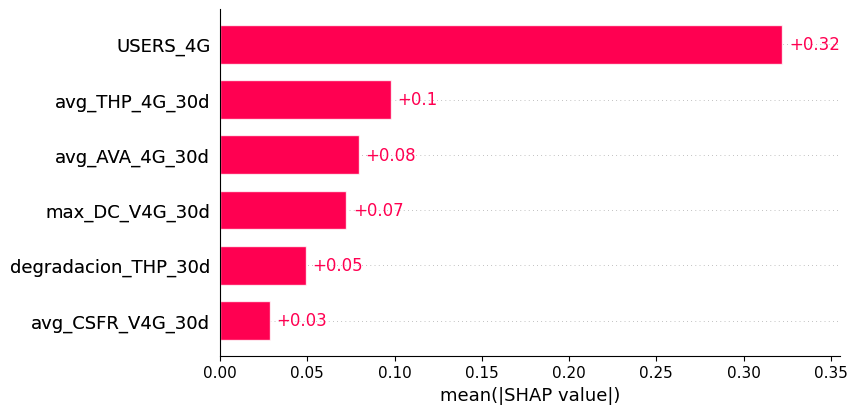

In [15]:
# 2. Generación y guardado del gráfico de barras (Importancia Global)
plt.figure(figsize=(10, 6))
# Usamos el objeto shap_values directo. Al pasarle .bar(), calcula la media de los valores absolutos de SHAP.
shap.plots.bar(shap_values, show=False)
fig_shap_bar = plt.gcf()

try:
    fig_shap_bar.savefig(FIGURES_DIR / "shap_global_bar.png", dpi=150, bbox_inches="tight")
    print(f"Éxito: Gráfico de barras SHAP guardado en '{FIGURES_DIR}/shap_global_bar.png'")
except NameError:
    fig_shap_bar.savefig("shap_global_bar.png", dpi=150, bbox_inches="tight")
    print("Éxito: Gráfico de barras SHAP guardado en el directorio raíz.")
plt.show()  # Se despliega en el notebook; el guardado en Drive ya quedó hecho arriba (referencia/documentación)

Éxito: Gráfico Beeswarm SHAP guardado en '/Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output/mensual/figures/shap_beeswarm.png'


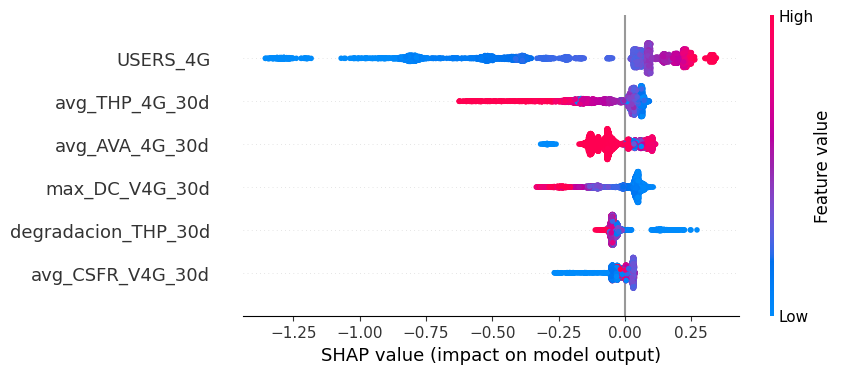

In [16]:
# 3. Generación y guardado del gráfico Beeswarm (Dirección del efecto)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=False)
fig_shap_scatter = plt.gcf()

try:
    fig_shap_scatter.savefig(FIGURES_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
    print(f"Éxito: Gráfico Beeswarm SHAP guardado en '{FIGURES_DIR}/shap_beeswarm.png'")
except NameError:
    fig_shap_scatter.savefig("shap_beeswarm.png", dpi=150, bbox_inches="tight")
    print("Éxito: Gráfico Beeswarm SHAP guardado en el directorio raíz.")
plt.show()  # Se despliega en el notebook; el guardado en Drive ya quedó hecho arriba (referencia/documentación)

In [17]:
# 4. Implementación de la función de Negocio: Clasificación de Acción Recomendada

# Umbral relativo a la magnitud típica de SHAP de este modelo, no un valor fijo --
# un umbral fijo (ej. 0.01) no se adapta a la escala real de las features y en la
# práctica casi nunca dispara "sin señal clara" (ver mvp_diagnostico_red-local.ipynb).
_SHAP_ABS_VALUES = np.abs(shap_values.values if hasattr(shap_values, "values") else shap_values)
SHAP_SIGNAL_THRESHOLD = 0.1 * _SHAP_ABS_VALUES.mean()


def clasifica_accion(shap_row: dict) -> str:
    """
    Retorna la acción recomendada basada en el driver SHAP dominante del sitio.

    Recibe un diccionario con las contribuciones SHAP de las variables para un registro específico.
    """
    # Identificar la variable con el impacto predictivo positivo más alto (que empuja hacia el Reclamo)
    driver_dominante = max(shap_row, key=shap_row.get)
    valor_maximo_shap = shap_row[driver_dominante]

    # Si el impacto predictivo de la variable dominante es insignificante, no hay señal clara
    if valor_maximo_shap <= SHAP_SIGNAL_THRESHOLD:
        return "Monitoreo"

    # Clasificación de acción según la naturaleza del driver dominante
    # throughput/capacidad crónico o volumen de usuarios alto
    if any(kpis in driver_dominante.lower() for kpis in ["thp", "users", "traffic", "capacidad"]):
        return "Inversión tecnológica"

    # problemas de disponibilidad, caídas de llamadas o fallos de conexión recurrentes (AVA / DC / CSFR)
    elif any(kpis in driver_dominante.lower() for kpis in ["ava", "dc", "csfr", "drop", "disponibilidad"]):
        return "Mantenimiento programado"

    else:
        return "Monitoreo"


# Ejemplo: se corre sobre el primer sitio del test set, para dejar constancia
# de que la función funciona antes de que §9 la use fila por fila.
_shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values
_ejemplo = dict(zip(FEATURE_COLS, _shap_array[0]))
print(f"Ejemplo -- driver por sitio: {_ejemplo}")
print(f"Acción recomendada: {clasifica_accion(_ejemplo)}")

print("§7 completado con éxito — Dev-2")

Ejemplo -- driver por sitio: {'avg_AVA_4G_30d': np.float32(-0.12147832), 'max_DC_V4G_30d': np.float32(0.0093338825), 'avg_THP_4G_30d': np.float32(0.064790174), 'degradacion_THP_30d': np.float32(-0.043574534), 'avg_CSFR_V4G_30d': np.float32(-0.046623524), 'USERS_4G': np.float32(0.32715878)}
Acción recomendada: Inversión tecnológica
§7 completado con éxito — Dev-2


> **Hallazgo:** El driver SHAP dominante a nivel global también es `USERS_4G` a grano mensual (importancia media |SHAP|=0.322), muy por encima de `avg_THP_4G_30d` (0.098, segundo lugar) y del resto de KPIs de calidad — mismo patrón encontrado a grano semanal, ahora confirmado en una agregación independiente con su propio split train/test.
> **Implicación:** el efecto de exposición (sitios con más usuarios generan más quejas mecánicamente, no necesariamente por peor calidad de red) no es un artefacto del grano semanal — se sostiene también a mes. Refuerza la limitación ya documentada para Entrega 3: el modelo prioriza tamaño/tráfico del sitio antes que degradación real de red, en ambos grano.

## §8 — Segmentación de sitios

**Owner:** Dev-3  
**Input:** `df_monthly` (features agregadas por sitio)  
**Output:** `df_sites_clustered` (con columnas `cluster` y `perfil`)  
**Dependencias:** §2 (Parquet)

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# TODO Dev-3:
# 1. Agregar df_monthly a nivel site_id (promedio del período)
# 2. StandardScaler sobre FEATURE_COLS
# 3. KMeans k=3..5, elegir k con silhouette score
# 4. Etiquetar clusters con perfil descriptivo
# 5. fig_cluster_scatter (PCA 2D o radar)

# df_sites_clustered esperado:
# site_id | avg_AVA | avg_DC | avg_THP | cluster | perfil

# fig_cluster_scatter.savefig(FIGURES_DIR / "cluster_sitios.png", dpi=150, bbox_inches="tight")

print("§8 pendiente — Dev-3")

§8 pendiente — Dev-3


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Agregación a nivel site_id -- usando df_model (ya limpio de §4: sin inf, sin NaN de rolling)
df_sites_agg = df_model.groupby(SITE_ID_COL)[FEATURE_COLS].mean().reset_index()

# 2. Escalado
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(df_sites_agg[FEATURE_COLS])

# 3. Selección de k por silhouette score
resultados_k = {}
for k in range(3, 6):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    resultados_k[k] = silhouette_score(X_cluster, labels)
    print(f"k={k}: silhouette={resultados_k[k]:.4f}")

best_k = max(resultados_k, key=resultados_k.get)
print(f"\nMejor k: {best_k} (silhouette={resultados_k[best_k]:.4f})")

# 4. Clustering final
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_sites_agg["cluster"] = kmeans_final.fit_predict(X_cluster)

# 5. Etiquetado de perfil -- basado en centroides reales vs. umbrales de negocio
centroides = df_sites_agg.groupby("cluster")[FEATURE_COLS].mean()
print("\nCentroides por cluster:")
print(centroides)

k=3: silhouette=0.3121


k=4: silhouette=0.3094
k=5: silhouette=0.3126

Mejor k: 5 (silhouette=0.3126)



Centroides por cluster:
         avg_AVA_4G_30d  max_DC_V4G_30d  avg_THP_4G_30d  degradacion_THP_30d  \
cluster                                                                        
0              0.998922        0.003814       15.346974             0.993220   
1              0.998226        0.006936       31.003203             1.037467   
2              0.999475        0.003715       38.068812             1.016965   
3              0.996656        0.787037       26.844921             1.145666   
4              0.763044        0.004736       20.123120             1.039176   

         avg_CSFR_V4G_30d   USERS_4G  
cluster                               
0                0.000914  72.002221  
1                0.000997  33.264195  
2                0.294878  11.634997  
3                0.033372  25.255096  
4                0.021287  36.886386  


In [20]:
def etiqueta_perfil(row):
    if row["avg_AVA_4G_30d"] < 0.90:  # muy por debajo del umbral 0.98 -- no un simple roce
        return "Crítico - disponibilidad severa"
    elif row["max_DC_V4G_30d"] > DC_THRESHOLD * 2:  # más del doble del umbral de negocio
        return "Crítico - caídas de llamada"
    elif row["avg_CSFR_V4G_30d"] > 0.05:  # outlier claro vs. el resto de clusters (~0.001-0.01)
        return "Crítico - fallas de conexión (CSFR)"
    elif row["avg_THP_4G_30d"] < THP_THRESHOLD_MBP * 1.05:  # en o por debajo del umbral
        return "Congestión de capacidad"
    else:
        return "Estable"

df_sites_agg["perfil"] = df_sites_agg.apply(etiqueta_perfil, axis=1)
print(df_sites_agg["perfil"].value_counts())
print()
print(df_sites_agg.groupby("perfil")[FEATURE_COLS].mean())  # verificación cruzada

perfil
Estable                                1657
Congestión de capacidad                 636
Crítico - caídas de llamada              33
Crítico - fallas de conexión (CSFR)       7
Crítico - disponibilidad severa           4
Name: count, dtype: int64

                                     avg_AVA_4G_30d  max_DC_V4G_30d  \
perfil                                                                
Congestión de capacidad                    0.998879        0.004056   
Crítico - caídas de llamada                0.993957        0.120872   
Crítico - disponibilidad severa            0.763044        0.004736   
Crítico - fallas de conexión (CSFR)        0.999497        0.004355   
Estable                                    0.998552        0.004025   

                                     avg_THP_4G_30d  degradacion_THP_30d  \
perfil                                                                     
Congestión de capacidad                   11.498470             0.988441   
Crítico - caídas de 

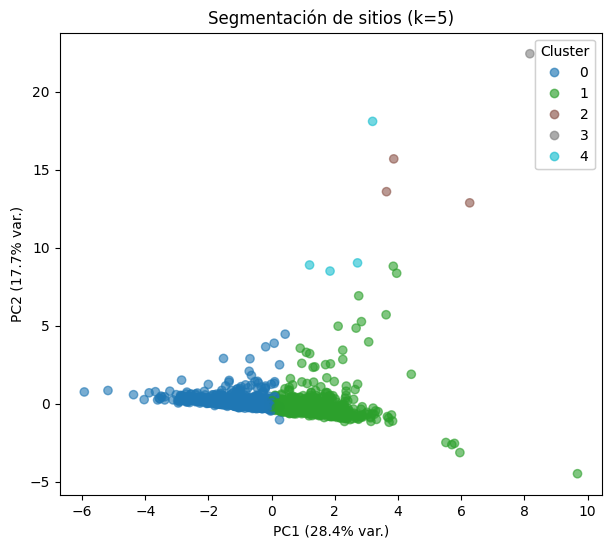

§8 completado — 2337 sitios en 5 clusters


In [21]:
# 6. Figura PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

fig_cluster_scatter, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=df_sites_agg["cluster"], cmap="tab10", alpha=0.6)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
ax.set_title(f"Segmentación de sitios (k={best_k})")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
fig_cluster_scatter.savefig(FIGURES_DIR / "cluster_sitios.png", dpi=150, bbox_inches="tight")
plt.show()

df_sites_clustered = df_sites_agg[[SITE_ID_COL, "avg_AVA_4G_30d", "max_DC_V4G_30d", "avg_THP_4G_30d", "cluster", "perfil"]].rename(
    columns={"avg_AVA_4G_30d": "avg_AVA", "max_DC_V4G_30d": "avg_DC", "avg_THP_4G_30d": "avg_THP"}
)
print(f"§8 completado — {len(df_sites_clustered)} sitios en {best_k} clusters")

**Hallazgo:** La segmentación a grano mensual (k=5, silhouette=0.313 — prácticamente igual al 0.31 obtenido a grano semanal) reproduce la misma estructura de grupos: mayoritario "Estable" (1,657 sitios, 70.9%), "Congestión de capacidad" (636, 27.2%), y tres grupos críticos pequeños: "Crítico - caídas de llamada" (33 sitios — casi el doble que los 17 detectados a grano semanal), "Crítico - fallas de conexión CSFR" (7, igual) y "Crítico - disponibilidad severa" (4, igual).
Implicación: la segmentación es estable entre grano semanal y mensual — la estructura de perfiles de sitio no depende de la resolución temporal elegida, lo que da confianza en que no es un artefacto del método. El grupo "Crítico - caídas de llamada" casi se duplica a grano mensual (33 vs 17 sitios), consistente con que `max_DC_V4G_30d` toma el máximo sobre una ventana de 30 días en vez de 7 — más oportunidad de capturar un pico real de caídas dentro del mes. Se mantiene la recomendación de agregar un umbral explícito de CSFR a las reglas de negocio.

## §9 — Ranking accionable (output final)

**Owner:** Dev-3  
**Input:** `df_monthly` (test), `y_prob_xgb`, `shap_values`, `df_sites_clustered`  
**Output:** `df_ranking` → `output/ranking_sitios.parquet`  
**Dependencias:** §5, §7, §8

In [22]:
# TODO Dev-3: construir df_ranking con schema:
# site_id | score_riesgo | prioridad_sitio | kpis_driver |
# umbral_incumplido | accion_recomendada | cluster | meses_en_riesgo

# df_ranking = df_test[[SITE_ID_COL]].copy()
# df_ranking["score_riesgo"] = y_prob_xgb
# df_ranking["prioridad_sitio"] = 0  # actualizar cuando cliente provea campo
# df_ranking["kpis_driver"] = ...    # top 2 features SHAP por sitio
# df_ranking["umbral_incumplido"] = ...
# df_ranking["accion_recomendada"] = df_ranking.apply(lambda r: clasifica_accion(...), axis=1)
# df_ranking = df_ranking.merge(df_sites_clustered[[SITE_ID_COL, "cluster"]], on=SITE_ID_COL, how="left")
# df_ranking["meses_en_riesgo"] = ...
# df_ranking = df_ranking.sort_values("score_riesgo", ascending=False)
# df_ranking.to_parquet(RANKING_PATH, index=False)

# print(f"Ranking guardado: {RANKING_PATH}")
# print(f"Top 10 sitios de mayor riesgo:")
# display(df_ranking.head(10))

print("§9 pendiente — Dev-3")

§9 pendiente — Dev-3


In [23]:
# 1. Base: site_id + score de riesgo (alineados posicionalmente con X_test)
df_ranking = df_test[[SITE_ID_COL]].reset_index(drop=True).copy()
df_ranking["score_riesgo"] = y_prob_xgb

# 2. Prioridad por terciles (provisional, hasta que el cliente defina el campo real)
df_ranking["prioridad_sitio"] = pd.qcut(
    df_ranking["score_riesgo"], q=3, labels=["Baja", "Media", "Alta"]
)

# 3. kpis_driver: top-2 features por |SHAP| en cada fila
# Nota: se incluye USERS_4G sin filtrar -- ver limitación documentada en §7/§9 sobre
# efecto de exposición vs. degradación real de red.
shap_array = shap_values.values if hasattr(shap_values, "values") else shap_values
top2_idx = np.argsort(-np.abs(shap_array), axis=1)[:, :2]
df_ranking["kpis_driver"] = [
    ", ".join([FEATURE_COLS[i] for i in fila]) for fila in top2_idx
]

# 4. umbral_incumplido: reglas de negocio violadas (reutiliza lógica de RulesBaseline)
def umbrales_violados(row):
    violados = []
    if row["avg_AVA_4G_30d"] < AVA_THRESHOLD:
        violados.append("AVA")
    if row["max_DC_V4G_30d"] > DC_THRESHOLD:
        violados.append("DC")
    if row["avg_THP_4G_30d"] < THP_THRESHOLD_MBP:
        violados.append("THP")
    return ", ".join(violados) if violados else "ninguno"

df_ranking["umbral_incumplido"] = X_test.reset_index(drop=True).apply(umbrales_violados, axis=1)

# 5. accion_recomendada: aplica clasifica_accion() fila por fila con el SHAP real, sin filtrar
df_ranking["accion_recomendada"] = [
    clasifica_accion(dict(zip(FEATURE_COLS, fila))) for fila in shap_array
]

# 6. Merge con clusters y perfil de §8
df_ranking = df_ranking.merge(
    df_sites_clustered[[SITE_ID_COL, "cluster", "perfil"]], on=SITE_ID_COL, how="left"
)

# 7. meses_en_riesgo: histórico completo por sitio (todo df_monthly, no solo test)
meses_riesgo = df_monthly.groupby(SITE_ID_COL)[TARGET_COL].sum().rename("meses_en_riesgo")
df_ranking = df_ranking.merge(meses_riesgo, on=SITE_ID_COL, how="left")

# 8. Deduplicar a nivel sitio: para cada site_id, quedarse con la fila de mayor score_riesgo
df_ranking = (
    df_ranking
    .sort_values("score_riesgo", ascending=False)
    .drop_duplicates(subset=SITE_ID_COL, keep="first")
    .reset_index(drop=True)
)

print(f"Total sitios únicos en ranking: {len(df_ranking)}")
print(f"¿Quedan duplicados? {df_ranking[SITE_ID_COL].duplicated().sum()}")

# 9. Orden final y guardado
df_ranking = df_ranking.sort_values("score_riesgo", ascending=False).reset_index(drop=True)
df_ranking.to_parquet(RANKING_PATH, index=False)

print(f"Ranking guardado: {RANKING_PATH}")
print(f"Total sitios en ranking: {len(df_ranking)}")
print("\nTop 10 sitios de mayor riesgo:")
display(df_ranking.head(10))

Total sitios únicos en ranking: 2335
¿Quedan duplicados? 0
Ranking guardado: /Users/guillermoventura/Documents/Maestria/TFM/TFM-grupo1/output/mensual/ranking_sitios.parquet
Total sitios en ranking: 2335

Top 10 sitios de mayor riesgo:


,site_id,score_riesgo,prioridad_sitio,kpis_driver,umbral_incumplido,accion_recomendada,cluster,perfil,meses_en_riesgo
0,959,0.661912,Alta,"USERS_4G, degradacion_THP_30d",ninguno,Inversión tecnológica,0,Congestión de capacidad,2
1,1506,0.661900,Alta,"USERS_4G, degradacion_THP_30d",ninguno,Inversión tecnológica,0,Estable,1
2,1745,0.658681,Alta,"USERS_4G, degradacion_THP_30d",THP,Inversión tecnológica,0,Congestión de capacidad,0
3,2577,0.653414,Alta,"USERS_4G, degradacion_THP_30d",ninguno,Inversión tecnológica,0,Estable,0
4,1485,0.647612,Alta,"USERS_4G, degradacion_THP_30d",ninguno,Inversión tecnológica,0,Estable,2
5,810,0.641969,Alta,"USERS_4G, degradacion_THP_30d",THP,Inversión tecnológica,0,Congestión de capacidad,0
6,45,0.640393,Alta,"USERS_4G, degradacion_THP_30d",THP,Inversión tecnológica,0,Congestión de capacidad,0
7,2567,0.639519,Alta,"USERS_4G, degradacion_THP_30d",THP,Inversión tecnológica,0,Congestión de capacidad,0
8,2582,0.638922,Alta,"USERS_4G, degradacion_THP_30d",THP,Inversión tecnológica,0,Congestión de capacidad,0
9,743,0.638622,Alta,"USERS_4G, degradacion_THP_30d",ninguno,Inversión tecnológica,0,Congestión de capacidad,1


In [24]:
# ¿Cuántos sitios distintos tiene realmente el patrón dominante del top 10?
print(df_ranking.head(30)[["kpis_driver", "umbral_incumplido", "cluster"]].value_counts())

# ¿Qué tan concentrado está el score de riesgo? Si el modelo distingue poco,
# los scores del top-N deberían estar muy cerca entre sí.
print(df_ranking["score_riesgo"].describe())
print(df_ranking.head(30)["score_riesgo"].std())

kpis_driver                    umbral_incumplido  cluster
USERS_4G, degradacion_THP_30d  THP                0          18
                               ninguno            0          10
USERS_4G, avg_AVA_4G_30d       THP                0           2
Name: count, dtype: int64
count    2335.000000
mean        0.459030
std         0.116959
min         0.107087
25%         0.379059
50%         0.502160
75%         0.546382
max         0.661912
Name: score_riesgo, dtype: float64
0.011683877


Hallazgo: igual que a grano semanal, el top de sitios de mayor riesgo muestra muy poca variación interna (std=0.012 en el top 30, frente a 0.117 en el ranking completo); 28 de los 30 sitios comparten el mismo par de drivers dominantes (`USERS_4G, degradacion_THP_30d`) y el mismo estado de umbral incumplido (THP o ninguno).
Implicación: la baja diferenciación dentro del grupo de mayor riesgo se repite a grano mensual — no es un artefacto de agregar por semana ni del tamaño de muestra semanal. Para uso operativo, `prioridad_sitio` (terciles Baja/Media/Alta) sigue siendo más confiable como criterio de triage que el orden exacto dentro del grupo "Alta", en ambos grano.

---

## Checklist de entrega

- [x] Kernel Restart → Run All completa sin error
- [x] `output/modeling_dataset_monthly.parquet` generado
- [x] `output/mensual/ranking_sitios.parquet` generado con 9 columnas (8 del schema + `perfil`)
- [x] `df_metrics` impreso con AUC-PR para los 3 modelos
- [x] Al menos 1 figura SHAP global en `output/figures/`
- [x] `RANDOM_STATE = 42` en todos los modelos
- [x] `TEST_CUTOFF_DATE` documentado con justificación (4 train / 2 test meses)
- [x] Variables con nombres definidos en `entregables/pipeline.md` (grano mensual, ver nota §0)